Installing the Gemini API SDK.
The Python SDK for the Gemini API is contained in the google-generativeai package.

In [31]:
pip install -q -U google-generativeai

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Setting up authentication
import os

# Assigning my API key to an environment variable
os.environ["API_KEY"] = "Your API Key"

# Importing and configuring the Google Generative AI library
import google.generativeai as genai

genai.configure(api_key=os.environ["API_KEY"])

Using the generateContent method to generate text from text-only input below.

In [3]:
try:
    # Initializing the GenerativeModel
    model = genai.GenerativeModel("gemini-1.5-flash")

    # Using the generateContent method to generate text
    response = model.generate_content("Write why 'when' is the most crucial aspect of evey uncertainiy, over 'what', 'how', 'why', and 'where'.")

    # Printing the generated text
    print(response.text)

except Exception as e:
    print(f"An error occurred: {e}")

While "what," "how," "why," and "where" are all important aspects of uncertainty, "when" is arguably the *most crucial* because it dictates the urgency and impact of the uncertain event.  Here's why:

* **Urgency and Actionability:**  Knowing *when* something uncertain might happen determines how urgently we need to respond.  Knowing *what* the uncertainty is (e.g., a potential market crash) is important, but without knowing *when* it might occur, it's difficult to plan effective mitigation strategies.  The "when" dictates the timeframe for action.

* **Resource Allocation:**  The "when" directly influences resource allocation.  If we know a potential disruption is imminent ("when" is soon), we can prioritize resources for immediate response. If the "when" is far off, resources can be allocated differently, potentially focusing on proactive measures or other priorities.

* **Risk Assessment and Mitigation:**  Accurate assessment of risk hinges on understanding the timing. A low-probabi

Generating text from text-and-image input below. The Gemini API supports multimodal inputs that combine text with media files. The following example shows how to generate text from text-and-image input. As with text-only prompting, multimodal prompting can involve various approaches and refinements.

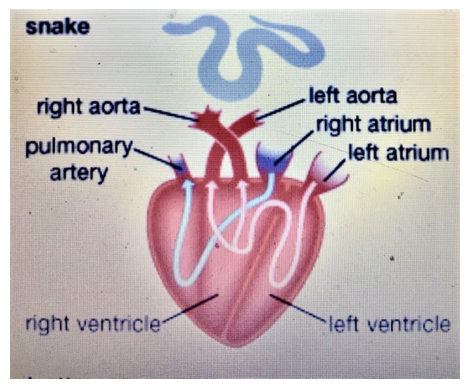

That's a diagram of a snake's heart.  Unlike the four-chambered hearts of mammals and birds, snakes have a three-chambered heart.  The diagram shows:

* **Two Atria (right and left):**  These are the receiving chambers of the heart. They collect blood returning to the heart.

* **One Ventricle:** This is the main pumping chamber.  While it's a single ventricle,  there is incomplete separation within it, allowing for some separation of oxygenated and deoxygenated blood. This incomplete separation is crucial to their unique circulatory system.

* **Right and Left Aortae:**  These are the major arteries carrying blood away from the heart.  The separation of the aortae at the heart's exit, is partly responsible for the partial separation of oxygenated and deoxygenated blood.

* **Pulmonary Artery:** This artery carries deoxygenated blood to the lungs for oxygenation.

The three-chambered heart with incomplete ventricle separation allows for a degree of separation of oxygenated and deoxygen

In [15]:
from PIL import Image
import matplotlib.pyplot as plt
from google.generativeai import GenerativeModel
from pathlib import Path

# Initializing the generative model
model = GenerativeModel("gemini-1.5-flash")

# Loading the image
media = Path(r"Your Path")  
image_path = media / "Your file name"

try:
    # Opening the image using PIL
    organ = Image.open(image_path)

    # Displaying the image inline using matplotlib
    plt.imshow(organ)
    plt.axis('off') 
    plt.show() 

    # Generating the response
    response = model.generate_content(["Tell me about this instrument", organ])
    print(response.text)

except FileNotFoundError:
    print("The specified image file was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Generating a text stream where the model returns a response after completing the entire text generation process below. We can achieve faster interactions by not waiting for the entire result, and instead use streaming to handle partial results.
The following example shows how to implement streaming using the streamGenerateContent method to generate text from a text-only input prompt.

In [9]:
from google.generativeai import GenerativeModel

# Initializing the generative model
model = GenerativeModel("gemini-1.5-flash")

# Requesting text generation with streaming enabled
response = model.generate_content("Write a story about a misunderstood genius.", stream=True)

# Printing the streamed content chunk by chunk
for chunk in response:
    print(chunk.text)  # Print the chunk text
    print("_" * 50)    # Separator for clarity

El
__________________________________________________
ara lived in a world of shimmering equations and whispering algorithms.  She saw patterns
__________________________________________________
 others missed – the fractal elegance of a spiderweb, the logarithmic spiral in a
__________________________________________________
 sunflower's seed head, the hidden music in the chaotic rhythm of a city's heartbeat.  But her genius, a torrent of insight that poured from
__________________________________________________
 her, was packaged in a form the world found unsettling.

Elara didn't speak in words easily understood.  Her communication was a symphony of symbols
__________________________________________________
 and diagrams, a visual language so complex and personal it was indecipherable to most.  Her attempts at verbal explanation were often met with blank stares, pitying smiles, or outright ridicule.  She'd try to explain the elegant
_________________________________________________

Building an interactive chat below.
We can use the Gemini API to build interactive chat experiences for our users. Using the chat feature of the API lets us collect multiple rounds of questions and responses, allowing users to step incrementally toward answers or get help with multipart problems. This feature is ideal for applications that require ongoing communication, such as chatbots, interactive tutors, or customer support assistants.
The following code example shows a basic chat implementation.

In [15]:
from google.generativeai import GenerativeModel

# Initializing the model
model = GenerativeModel("gemini-1.5-flash")

def start_new_chat():
    # Starting a fresh chat session with no history
    chat = model.start_chat(
        history=[
            {"role": "user", "parts": "Hello"},
            {"role": "model", "parts": "Great to meet you. What would you like to know?"},
        ]
    )
    return chat

# Beginning the first chat session
chat = start_new_chat()
print("Chatbot: Great to meet you. What would you like to know?")

while True:
    user_input = input("You: ")
    
    if user_input.lower() in {"exit", "quit"}:
        print("Chatbot: Goodbye!")
        break
    elif user_input.lower() in {"restart", "new chat"}:
        # Restart the chat
        print("Chatbot: Starting a new chat session.")
        chat = start_new_chat()
        print("Chatbot: Great to meet you again. What would you like to know?")
        continue

    # Sending the message and printing the model's response
    response = chat.send_message(user_input)
    print(f"Chatbot: {response.text}")

Chatbot: Great to meet you. What would you like to know?


You:  hi


Chatbot: Hi there! How can I help you today?



You:  Generate a short poem on a wintery afternoon sky


Chatbot: The sun, a pale and watery gleam,
Hangs low, a ghost in winter's dream.
Grey clouds, like sheep on frosted hills,
Drift slow, as icy wind chills.
A robin's song, a fleeting sound,
Before the twilight shadows bound.
The sky, a canvas, cold and vast,
Where winter's beauty lingers fast.



...

Chatbot: Starting a new chat session.
Chatbot: Great to meet you again. What would you like to know?


You:  tell me how the lion killed the croc


Chatbot: There's no single, universally known story of a lion killing a crocodile.  Lions and crocodiles are apex predators in their respective environments, and encounters between them are rare but often deadly for one or both animals.  The outcome depends heavily on factors like:

* **Size and age of the animals:** A large, mature lion could potentially kill a smaller crocodile, while the reverse is also true.  A large crocodile could easily kill a lion cub or a young, weak lion.

* **Location of the encounter:**  A lion might have a better advantage on land, while a crocodile would be stronger in the water.

* **Surprise and opportunity:**  An ambush by either predator could drastically alter the outcome.

There are anecdotal accounts and possibly even videos showing lions successfully killing crocodiles, usually involving a lion dragging a crocodile out of the water onto land where the lion has a significant advantage.  However, there isn't a classic, widely known tale like "The Li

You:  exit


Chatbot: Goodbye!


Enabling chat streaming below, which is the process of receiving the response from a model, such as a chatbot or a language generation model, in real-time as the response is being generated, rather than waiting for the entire response to be fully produced and returned in one large block.
It is achieved by enabling streaming (typically via a stream=True). We can use streaming with chat, as shown in the following example:

In [ ]:
from google.generativeai import GenerativeModel

# Initializing the model
model = GenerativeModel("gemini-1.5-flash")

def start_new_chat():
    # Starting a fresh chat session with no history
    chat = model.start_chat(
        history=[
            {"role": "user", "parts": "Hello"},
            {"role": "model", "parts": "Great to meet you. What would you like to know?"},
        ]
    )
    return chat

# Beginning the first chat session
chat = start_new_chat()
print("Chatbot: Great to meet you. What would you like to know?")

while True:
    user_input = input("You: ")
    
    if user_input.lower() in {"exit", "quit"}:
        print("Chatbot: Goodbye!")
        break
    elif user_input.lower() in {"restart", "new chat"}:
        # Restart the chat
        print("Chatbot: Starting a new chat session.")
        chat = start_new_chat()
        print("Chatbot: Great to meet you again. What would you like to know?")
        continue

    # Sending the message with streaming enabled and print the model's response chunk by chunk
    response = chat.send_message(user_input, stream=True)  # Enable streaming
    for chunk in response:
        print(chunk.text, end="")  # Printing each chunk as it's received, without a newline
    print()  # Newline after the complete response

Chatbot: Great to meet you. What would you like to know?


You:  Hi


Hi there! How can I help you today?



You:  Generate a short poem on a wintery afternoon sky


The sun, a pale and distant gleam,
Hangs low, a blush on winter's dream.
Grey clouds, like sheep across the blue,
Drift slow, in skies of frosted hue.
A chilling wind begins to sigh,
As shadows lengthen, and day dies.



...

You:  bye


Goodbye! Have a great day.



You:  bye


Bye!



You:  new chat


Configuring text generation below.
Every prompt we send to the model includes parameters that control how the model generates responses. We can use GenerationConfig to configure these parameters. If we don't configure the parameters, the model uses default options, which can vary by model.

The code initializes a generative model (gemini-1.5-flash) with a custom configuration, including a stop sequence ("t") and a token limit (1000). It then generates content (a story about a three-horned unicorn) with streaming enabled, meaning the response is received in chunks. Each chunk is appended to full_response, and once all chunks are collected, the complete story is printed.

In [5]:
from google.generativeai import GenerativeModel, types

# Initializing the model
model = GenerativeModel("gemini-1.5-flash")

# Creating generation config
generation_config = types.GenerationConfig(
    candidate_count=1,
    stop_sequences=["t"],  # Optional: We can Use if we want to stop at specific sequences. Here, the generation will stop as soon as it encounters 't'.
    max_output_tokens=1000,  
    temperature=1.0
)

# Generating content with specific config and streaming enabled
response = model.generate_content(
    "Tell me a story about a three horned unicorn.",
    generation_config=generation_config,
    stream=True  # Enabling streaming for incremental response
)

# Collecting the complete response from the chunks
full_response = ""
for chunk in response:
    full_response += chunk.text  # Appending each chunk's text

# Printing the full story once all chunks are received
print(full_response)

The wind whispered secre


The below code initializes the gemini-1.5-flash model with a custom configuration, setting a stop sequence ("The End") and increasing the token limit (3000). It generates a story about a three-horned unicorn with streaming enabled, meaning the response is received in chunks. Each chunk is appended to full_response, and once all chunks are collected, the complete story is printed.

In [5]:
from google.generativeai import GenerativeModel, types

# Initializing the model
model = GenerativeModel("gemini-1.5-flash")

# Creating generation config
generation_config = types.GenerationConfig(
    candidate_count=1,
    stop_sequences=["The End"],  
    max_output_tokens=3000,  
    temperature=1.0
)

# Generating content with specific config and streaming enabled
response = model.generate_content(
    "Create a story about a three horned unicorn.",
    generation_config=generation_config,
    stream=True  # Enable streaming for incremental response
)

# Collecting the complete response from the chunks
full_response = ""
for chunk in response:
    full_response += chunk.text  # Appending each chunk's text

# Printing the full story once all chunks are received
print(full_response)

The wind whispered secrets through the razorgrass, rustling against the three spiraling horns of Zephyr. Unlike the elegant, single-horned unicorns of legend, Zephyr was a creature of stark contrasts. His coat, the color of twilight, was perpetually dusted with volcanic ash from the caldera where he made his home. His three horns, obsidian black and tipped with shimmering amethyst, pulsed faintly with an inner light.  He was a creature of shadow and fire, a paradox embodied.

For centuries, Zephyr had lived in isolation, a silent guardian of the caldera's geothermal vents. The villagers of Oakhaven, nestled in the valley below, spoke of him in hushed tones – a creature of nightmare, a harbinger of doom. They were wrong, of course, but fear, like the caldera’s smoke, obscured the truth.

One day, a tremor shook the land, far stronger than any before.  A fissure opened on the caldera's edge, spewing molten rock and sending a wave of searing heat down towards Oakhaven.  Elara, a young gir

The below code initializes the gemini-1.5-flash model with a configuration allowing up to 1000 tokens in the response and a low temperature (0.1) for more deterministic output. It generates a story about a three-horned unicorn with streaming enabled, meaning the story is generated in chunks. Each chunk is printed as it streams, using end="" to avoid adding extra newlines after each chunk.

In [13]:
from google.generativeai import GenerativeModel, types

# Initializing the model
model = GenerativeModel("gemini-1.5-flash")

# Creating generation config
generation_config = types.GenerationConfig(
    max_output_tokens=1000,   
    temperature=0.1           # Lower temperature for more deterministic output
)

# Generating content with specific config, using stream=True
response = model.generate_content(
    'Write a story about a three horned unicorn.',
    generation_config=generation_config, stream=True
)

# Printing the generated response in chunks as it streams
for chunk in response:
    print(chunk.text, end="")  # Using 'end=""' to avoid double newline

The wind whispered secrets through the whispering willows that bordered the Whispering Glade, secrets only Zephyr, the three-horned unicorn, could understand.  His third horn, a spiraling obsidian spike nestled between his pearly white ones, pulsed with a faint, inner light – a beacon of his unique magic.  Unlike the graceful, ethereal unicorns of legend, Zephyr was a creature of shadows and starlight, his coat the colour of midnight, his eyes twin pools of molten silver.

He wasn't welcomed in the sun-dappled meadows where the other unicorns grazed.  They feared his third horn, a deviation from their perfect symmetry, a mark of something… different.  They whispered of him being a harbinger of ill fortune, a creature born of darkness.  Zephyr, however, found solace in the solitude of the Whispering Glade, his magic thriving in the twilight.

His power wasn't the gentle healing touch of the other unicorns.  Zephyr's magic was a potent, untamed force, capable of manipulating shadows and 